# Sistemas Dinámicos: Hegselmann-Krause y Kuramoto
**Módulo 4 — Sistemas Dinámicos y Solución Numérica de EDOs**

**Programación Científica 2026-1 · Universidad Nacional de Colombia**  
mbastidaso@unal.edu.co

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/)

---

Este notebook implementa y visualiza un modelo de dinámica social:

1. **Hegselmann-Krause (H-K)**: polarización de opiniones bajo un umbral de confianza $\varepsilon$.

Se resuelve con **Euler explícito** y **Runge-Kutta de orden 4 (RK4)**.


In [1]:
# ── Instalación de LaTeX para renderizado tipográfico (descomentar en Colab) ──
!sudo apt-get update -qq
!sudo apt-get install -qq texlive-latex-extra texlive-fonts-recommended dvipng cm-super

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize

# ── Configuración global de estilo matplotlib ────────────────────────────────
# Renderiza etiquetas con LaTeX y fuente serif (Computer Modern), igual que
# los slides de la clase. Mejora la legibilidad en figuras publicables.
plt.rcParams.update({
    "text.usetex"        : True,
    "font.family"        : "serif",
    "font.serif"         : ["Computer Modern Roman"],
    "font.size"          : 14,

    # Ejes y ticks
    "axes.labelsize"     : 16,
    "axes.titlesize"     : 18,
    "xtick.labelsize"    : 12,
    "ytick.labelsize"    : 12,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction"    : "in",
    "ytick.direction"    : "in",

    # Grilla
    "grid.color"         : "gray",
    "grid.linewidth"     : 0.3,
    "grid.alpha"         : 0.3,
    "grid.linestyle"     : "--",

    # Estética general
    "figure.dpi"         : 120,
    "axes.spines.top"    : False,
    "axes.spines.right"  : False,
    "savefig.bbox"       : "tight",
    "savefig.dpi"        : 300,
})
print("Configuración OK")


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 56.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-droid-fallback.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../00-fonts-droid-fallback_1%3a6.0.1r16-1.1build1_all.deb ...
Unpacking fonts-droid-fallback (1:6.0.1r16-1.1build1) ...
Selecting previously unselected package fonts-lato.
Preparing to unpack .../01-fonts-

---
## Parte 1 — Modelo de Hegselmann-Krause (H-K)

El modelo H-K captura cómo los agentes actualizan sus opiniones
$x_i(t) \in [-1, 1]$ interactuando **solo** con quienes tienen opiniones cercanas:

$$
\dot{x}_i(t) =
\frac{1}{|\mathcal{N}_i(t)|}
\sum_{j \in \mathcal{N}_i(t)} \!\bigl(x_j(t) - x_i(t)\bigr),
\qquad
\mathcal{N}_i(t) = \{j : |x_j(t) - x_i(t)| < \varepsilon\}.
$$

El umbral $\varepsilon > 0$ modela el **radio de confianza**:
si la diferencia de opiniones supera $\varepsilon$, el agente $i$ ignora al agente $j$.


### 1.1 Campo vectorial para $N=2$ agentes

Con dos agentes el espacio de estados es $[-1,1]^2$.
El campo vectorial $(\dot{x}_1, \dot{x}_2)$ muestra cómo evoluciona
el par de opiniones en cada punto del plano.

La **banda azul** señala la región de interacción $|x_2 - x_1| < \varepsilon$.
Fuera de ella el campo es cero: no hay cambio de opinión.


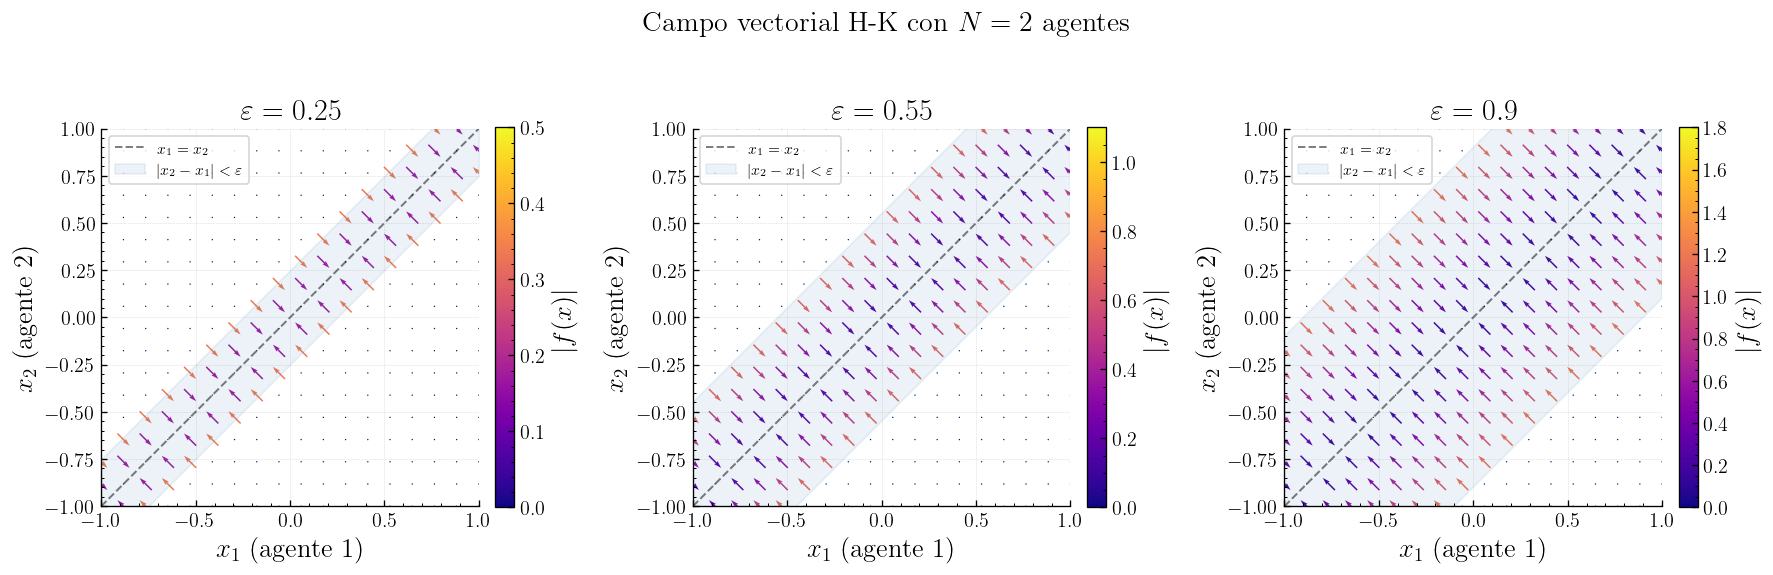

In [2]:
# ── Campo vectorial H-K para N=2 agentes ────────────────────────────────────
# Se visualiza para tres umbrales representativos:
#   ε = 0.25 → muy restrictivo: fragmentación total
#   ε = 0.55 → intermedio: posible polarización en dos clusters
#   ε = 0.90 → permisivo: consenso global

eps_vals = [0.25, 0.55, 0.90]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, eps in zip(axes, eps_vals):
    # Malla de puntos en el espacio de estados [−1, 1]²
    x1, x2 = np.meshgrid(np.linspace(-1, 1, 18), np.linspace(-1, 1, 18))

    # Diferencia de opiniones entre los dos agentes
    diff = x2 - x1

    # Máscara: True donde los agentes están dentro del radio de confianza
    inside = np.abs(diff) < eps

    # Campo vectorial: cada agente se mueve hacia el otro si están dentro del radio
    # Fuera del radio: no hay interacción (campo = 0)
    dx1 = np.where(inside,  diff, 0.0)   # ẋ₁ = (x₂ − x₁) si |diff| < ε, else 0
    dx2 = np.where(inside, -diff, 0.0)   # ẋ₂ = (x₁ − x₂) si |diff| < ε, else 0

    # Magnitud del campo para el colormap
    mag = np.sqrt(dx1**2 + dx2**2)
    nf  = np.where(mag > 0, mag, 1.0)    # denominador seguro (evitar 0/0)

    # Quiver: flechas normalizadas coloreadas por magnitud
    qv = ax.quiver(x1, x2, dx1/nf, dx2/nf, mag,
                   cmap="plasma", scale=22, width=0.004, pivot="mid",
                   clim=[0, 2*eps])
    plt.colorbar(qv, ax=ax, label=r"$|f(x)|$", fraction=0.046, pad=0.04)

    # Diagonal x₁ = x₂: todo punto sobre esta recta es un estado de consenso
    ax.plot([-1, 1], [-1, 1], "k--", lw=1.2, alpha=0.5, label=r"$x_1 = x_2$")

    # Banda de confianza: zona donde los dos agentes interactúan
    ax.fill_between([-1, 1], [-1 - eps, 1 - eps], [-1 + eps, 1 + eps],
                    alpha=0.10, color="steelblue",
                    label=r"$|x_2 - x_1| < \varepsilon$")

    ax.set_xlim(-1, 1); ax.set_ylim(-1, 1)
    ax.set_xlabel(r"$x_1$ (agente 1)")
    ax.set_ylabel(r"$x_2$ (agente 2)")
    ax.set_title(fr"$\varepsilon = {eps}$")
    ax.set_aspect("equal")
    ax.legend(fontsize=9, loc="upper left")
    ax.grid(True)

plt.suptitle(r"Campo vectorial H-K con $N=2$ agentes")
plt.tight_layout()
plt.show()


### 1.2 Implementación: Euler explícito y Runge-Kutta 4

#### Euler explícito
Truncar la serie de Taylor al primer orden:
$$x_{n+1} = x_n + \Delta t \, f(x_n,\, t_n). $$
-  Error global acumulado: $O(\Delta t)$.

#### Runge-Kutta 4
Promediar cuatro evaluaciones de $f$ con pesos de Simpson:
$$x_{n+1} = x_n + \frac{\Delta t}{6}(k_1 + 2k_2 + 2k_3 + k_4).$$
-  Error global: $O(\Delta t^4)$.


In [3]:
# ── RHS del modelo H-K ──────────────────────────────────────────────────────
def hk_rhs(x, t, eps):
    """
    Lado derecho de la EDO de Hegselmann-Krause.

    Parámetros
    ----------
    x   : (N,) ndarray — opiniones actuales de los N agentes
    t   : float        — tiempo (no se usa: el sistema es autónomo)
    eps : float        — umbral de confianza ε

    Retorna
    -------
    dxdt : (N,) ndarray — tasas de cambio ẋᵢ
    """
    N    = len(x)
    dxdt = np.zeros(N)
    for i in range(N):
        # Vecinos de i: todos los j con |xⱼ − xᵢ| < ε (incluido i mismo)
        vecinos = np.where(np.abs(x - x[i]) < eps)[0]
        if len(vecinos) > 0:
            # El agente i se mueve hacia el promedio de su vecindad
            dxdt[i] = x[vecinos].mean() - x[i]
    return dxdt


# ── Euler explícito ─────────────────────────────────────────────────────────
def euler(f, x0, t, **kw):
    """
    Integrador de Euler explícito de primer orden.
    x_{n+1} = x_n + Δt · f(x_n, t_n)

    Parámetros
    ----------
    f   : callable f(x, t, **kw) — campo vectorial
    x0  : (N,) ndarray            — condición inicial
    t   : (M,) ndarray            — tiempos de salida
    **kw: parámetros extra para f

    Retorna
    -------
    X : (M, N) ndarray — trayectoria aproximada
    """
    X    = np.zeros((len(t), len(x0)))
    X[0] = x0
    for n in range(len(t) - 1):
        dt       = t[n+1] - t[n]             # permite paso variable
        X[n+1]   = X[n] + dt * f(X[n], t[n], **kw)
    return X


# ── Runge-Kutta de orden 4 ───────────────────────────────────────────────────
def rk4(f, x0, t, **kw):
    """
    Integrador de Runge-Kutta de orden 4.
    Promedia cuatro evaluaciones de f para alcanzar error local O(Δt⁵).

    Parámetros
    ----------
    f   : callable f(x, t, **kw) — campo vectorial
    x0  : (N,) ndarray            — condición inicial
    t   : (M,) ndarray            — tiempos de salida
    **kw: parámetros extra para f

    Retorna
    -------
    X : (M, N) ndarray — trayectoria aproximada
    """
    X    = np.zeros((len(t), len(x0)))
    X[0] = x0
    for n in range(len(t) - 1):
        dt = t[n+1] - t[n]
        k1 = f(X[n],              t[n],          **kw)  # pendiente al inicio
        k2 = f(X[n] + dt/2 * k1, t[n] + dt/2,   **kw)  # pendiente medio (usando k1)
        k3 = f(X[n] + dt/2 * k2, t[n] + dt/2,   **kw)  # pendiente medio (usando k2)
        k4 = f(X[n] + dt   * k3, t[n] + dt,      **kw)  # pendiente al final
        # Promedio ponderado: extremos × 1, puntos medios × 2
        X[n+1] = X[n] + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)
    return X


print("Funciones definidas: hk_rhs, euler, rk4")


Funciones definidas: hk_rhs, euler, rk4


### 1.3 Simulación H-K: efecto del umbral $\varepsilon$

Se simulan $N = 30$ agentes con opiniones iniciales uniformes en $[-1, 1]$
para tres valores de $\varepsilon$.  
Se espera observar: **fragmentación** (ε pequeño), **polarización** (ε intermedio), **consenso** (ε grande).


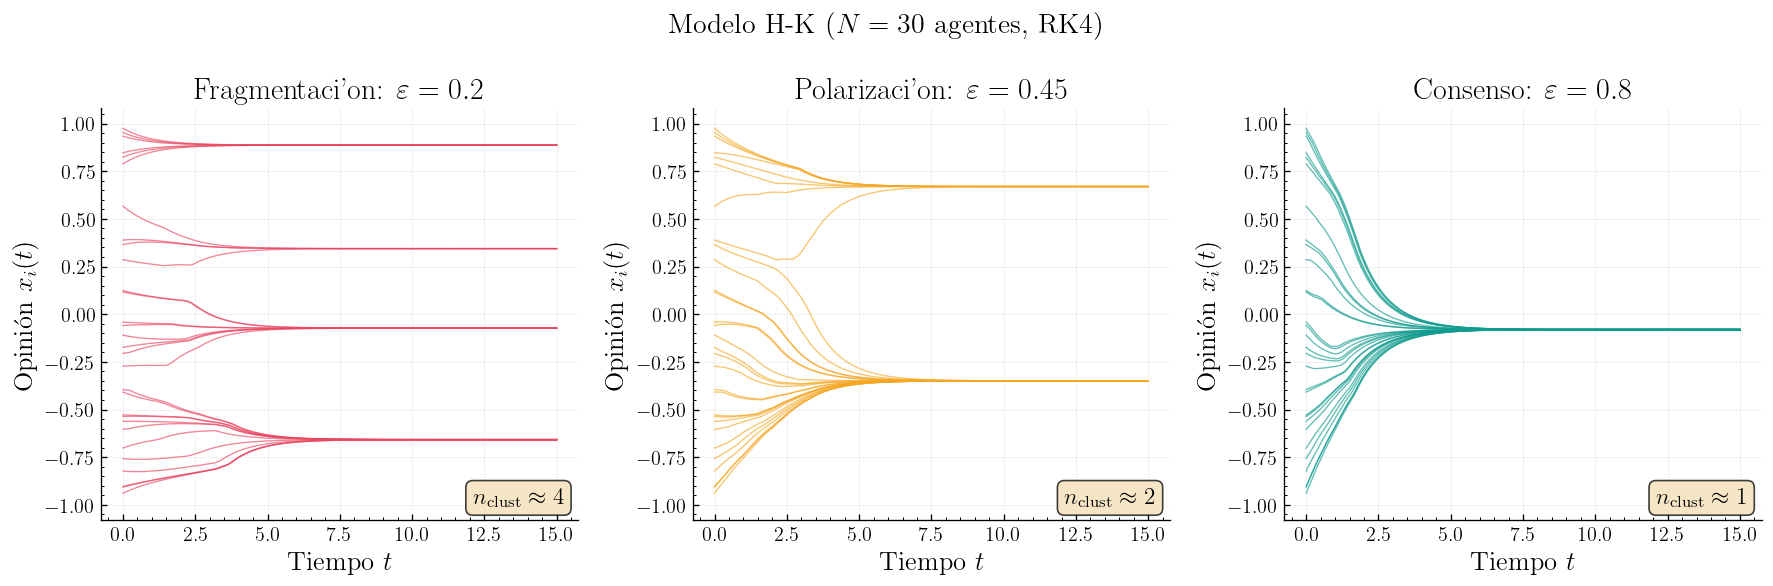

In [4]:
# ── Simulación H-K: N=30, tres umbrales ─────────────────────────────────────
np.random.seed(2026)                          # reproducibilidad

N     = 30                                    # número de agentes
T     = 15.0                                  # horizonte temporal
dt    = 0.05                                  # paso de tiempo (RK4 tolera pasos grandes)
t_arr = np.arange(0, T + dt, dt)             # array de tiempos

# Condición inicial: opiniones uniformes en [−1, 1]
x0 = np.random.uniform(-1, 1, N)

eps_list = [0.20, 0.45, 0.80]               # los tres regímenes
titulos  = ["Fragmentaci\'on", "Polarizaci\'on", "Consenso"]
colores  = ["#E94560", "#F5A623", "#0F9B8E"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, eps, titulo, col in zip(axes, eps_list, titulos, colores):
    # Resolver la EDO con RK4 (más preciso para visualización)
    X = rk4(hk_rhs, x0, t_arr, eps=eps)

    # Graficar la trayectoria de cada agente
    for i in range(N):
        ax.plot(t_arr, X[:, i], lw=0.8, alpha=0.65, color=col)

    # Estimar el número de clusters finales
    # Ordenar las opiniones finales y contar brechas > ε
    x_final = np.sort(X[-1])
    gaps     = np.diff(x_final)
    n_clust  = 1 + int(np.sum(gaps > eps))

    ax.set_xlabel(r"Tiempo $t$")
    ax.set_ylabel(r"Opini\'on $x_i(t)$")
    ax.set_title(fr"{titulo}: $\varepsilon = {eps}$")
    ax.set_ylim(-1.08, 1.08)
    # Caja de texto con el número de clusters en la esquina inferior derecha
    ax.text(0.97, 0.04, fr"$n_{{\rm clust}} \approx {n_clust}$",
            transform=ax.transAxes, ha="right",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.75))
    ax.grid(True)

plt.suptitle(r"Modelo H-K ($N=30$ agentes, RK4)")
plt.tight_layout()
plt.show()


### 1.4 Convergencia: Euler vs. RK4

Se mide el error $\|x(T) - x_{\rm ref}(T)\|_2$ respecto a una solución
de referencia (RK4 con $\Delta t_{\rm ref} = 10^{-4}$) en función de $\Delta t$.

En escala logarítmica, una recta de pendiente $p$ corresponde a un método de orden $p$.


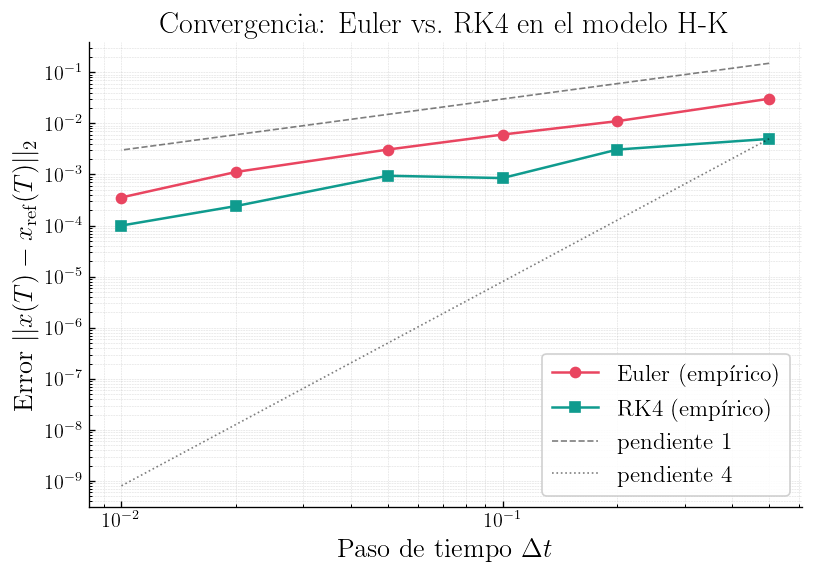

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# ── Convergencia de Euler y RK4 en el modelo H-K ──────────────
# Se usa una condición inicial pequeña fija y un epsilon donde la dinámica
# es suave para que la comparación sea limpia.

N_c    = 5
x0_c   = np.array([-0.80, -0.30, 0.00, 0.40, 0.75])
eps_c  = 0.60
T_c    = 4.0
#solucion de referencia numerica de alta precision

# Solución de referencia: RK4 con paso muy pequeño
dt_ref   = 1e-4
t_ref    = np.arange(0, T_c + dt_ref, dt_ref)
X_ref    = rk4(hk_rhs, x0_c, t_ref, eps=eps_c)
x_end    = X_ref[-1]  # estado final de referencia

# Barrido de pasos de tiempo
dts      = [0.50, 0.20, 0.10, 0.05, 0.02, 0.01]
err_eu   = []   # errores de Euler
err_rk   = []   # errores de RK4

for dt_ in dts:
    t_ = np.arange(0, T_c + dt_, dt_)

    # Error de Euler: norma del estado final vs referencia
    Xe = euler(hk_rhs, x0_c, t_, eps=eps_c)
    err_eu.append(np.linalg.norm(Xe[-1] - x_end))

    # Error de RK4
    Xr = rk4(hk_rhs, x0_c, t_, eps=eps_c)
    err_rk.append(np.linalg.norm(Xr[-1] - x_end))

dts_arr = np.array(dts)

fig, ax = plt.subplots(figsize=(7, 5))

# Errores de cada método
ax.loglog(dts_arr, err_eu, "o-", color="#E94560", lw=1.5, label="Euler (empírico)")
ax.loglog(dts_arr, err_rk, "s-", color="#0F9B8E", lw=1.5, label="RK4 (empírico)")

# Rectas de referencia teóricas (pendientes 1 y 4)
ax.loglog(dts_arr, 0.30 * dts_arr**1, "k--", lw=1, alpha=0.5, label="pendiente 1")
ax.loglog(dts_arr, 0.08 * dts_arr**4, "k:",  lw=1, alpha=0.5, label="pendiente 4")

ax.set_xlabel(r"Paso de tiempo $\Delta t$")
ax.set_ylabel(r"Error $||x(T) - x_{\rm ref}(T)||_2$")
ax.set_title(r"Convergencia: Euler vs.\ RK4 en el modelo H-K")
ax.legend(framealpha=0.9)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

### ¿Pasó lo que esperaba? ¿La convergencia es ideal? ¿Qué método se debe usar para este problema?

**Será algún error de implementación?**

### Existen funciones de Python para resolver EDO's ¿cuáles son? y ¿qué hacen?

**Pregunta para Manu:** ¿Las podemos usar?